In [2]:
import matplotlib.pyplot as plt
# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

### 240918

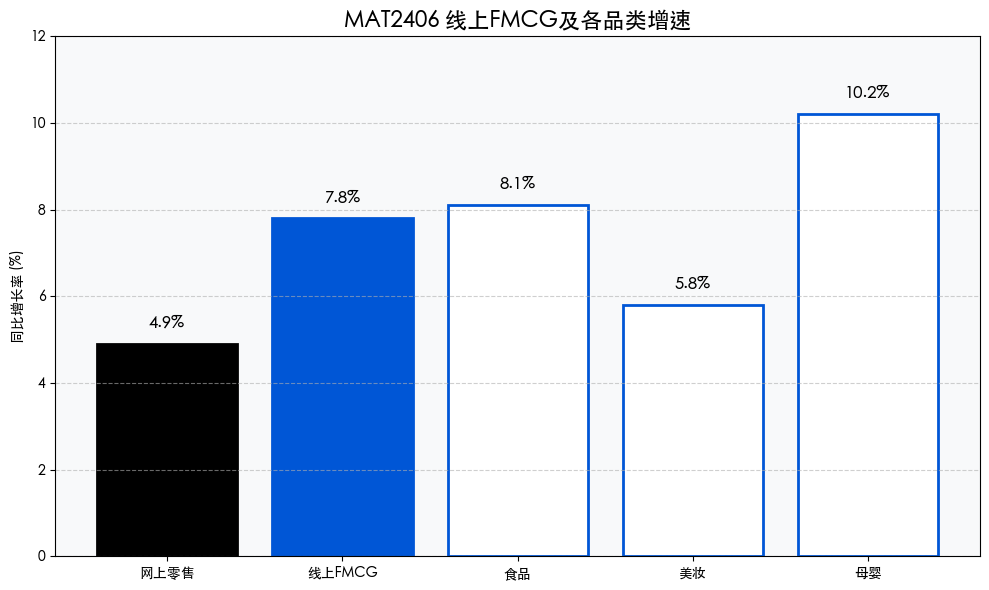

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# 图表1：MAT2406 线上FMCG及各品类增速（使用柱状图）
categories = ['网上零售', '线上FMCG', '食品', '美妆', '母婴']
growth = [4.9, 7.8, 8.1, 5.8, 10.2]
colors = ['black', '#0056d6', 'white', 'white', 'white']
edgecolors = ['black', '#0056d6', '#0056d6', '#0056d6', '#0056d6']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(categories, growth, color=colors, edgecolor=edgecolors, linewidth=2)

# 添加数值标签
for bar, value in zip(bars, growth):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.3, f'{value}%', ha='center', va='bottom', fontsize=12)

# 设置标题与Y轴标签
ax.set_title('MAT2406 线上FMCG及各品类增速', fontsize=16)
ax.set_ylabel('同比增长率 (%)')
ax.set_ylim(0, 12)
ax.set_facecolor('#f8f9fa')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


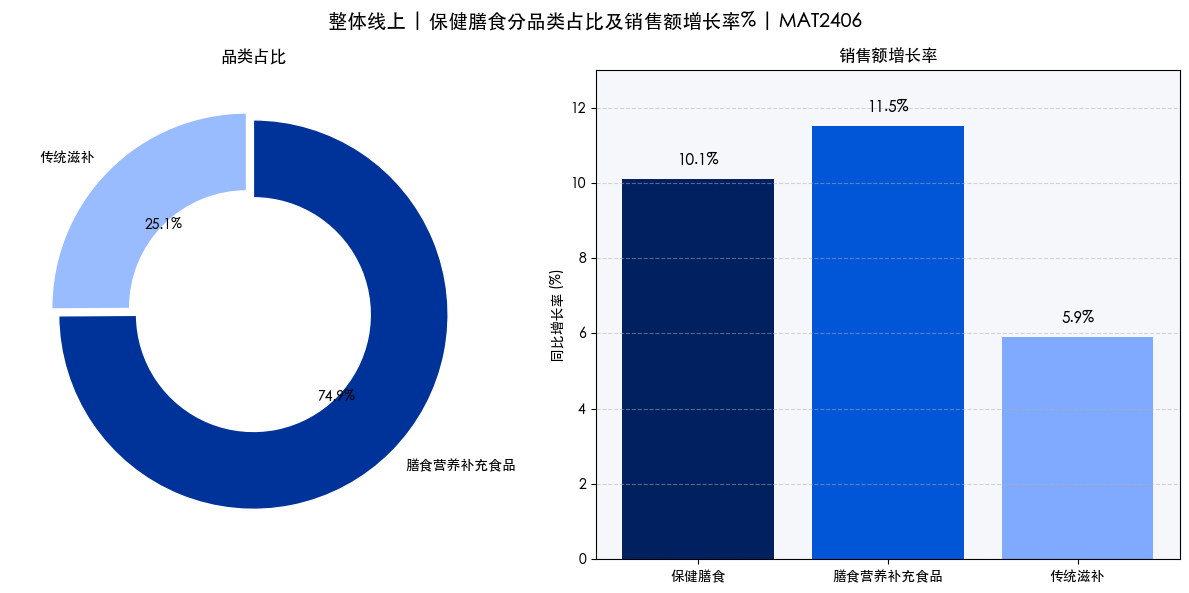

In [4]:
# 图表2：健康膳食品类占比 + 增速（饼图+柱状图组合）

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={'width_ratios': [1, 1.2]})
fig.suptitle('整体线上 | 保健膳食分品类占比及销售额增长率% | MAT2406', fontsize=14)

# 饼图数据
labels = ['膳食营养补充食品', '传统滋补']
sizes = [74.9, 25.1]
colors = ['#003399', '#99bbff']
explode = (0, 0.05)

# 饼图（圆环）
wedges, texts, autotexts = ax1.pie(
    sizes, labels=labels, autopct='%1.1f%%', startangle=90, counterclock=False,
    colors=colors, wedgeprops=dict(width=0.4, edgecolor='w'), explode=explode, textprops={'fontsize': 10}
)
ax1.set_title('品类占比')

# 柱状图数据
sub_categories = ['保健膳食', '膳食营养补充食品', '传统滋补']
growth_rates = [10.1, 11.5, 5.9]
bar_colors = ['#002060', '#0056d6', '#7faaff']

bars = ax2.bar(sub_categories, growth_rates, color=bar_colors)

# 添加数值标签
for bar, value in zip(bars, growth_rates):
    ax2.text(bar.get_x() + bar.get_width()/2, value + 0.3, f'{value}%', ha='center', va='bottom', fontsize=11)

# 样式细节
ax2.set_ylim(0, 13)
ax2.set_ylabel('同比增长率 (%)')
ax2.set_title('销售额增长率')
ax2.grid(axis='y', linestyle='--', alpha=0.5)
ax2.set_facecolor('#f5f7fa')

plt.tight_layout()
plt.show()


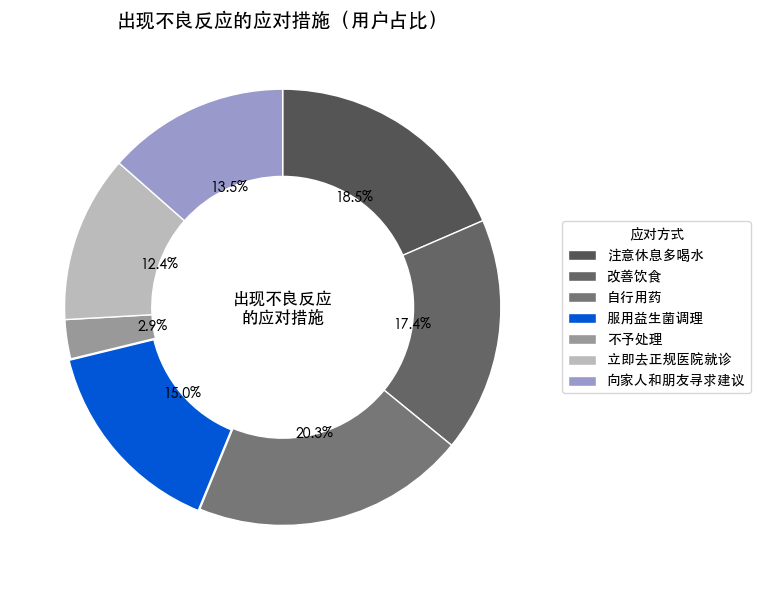

In [5]:
# 图表3：不良反应的应对措施（高亮特定扇区的环形图）

# 数据
labels = [
    '注意休息多喝水', '改善饮食', '自行用药',
    '服用益生菌调理', '不予处理', '立即去正规医院就诊', '向家人和朋友寻求建议'
]
sizes = [18.5, 17.4, 20.3, 15.0, 2.9, 12.4, 13.5]
highlight_index = 3  # 高亮“服用益生菌调理”

# 定义颜色和突出项
colors = ['#555', '#666', '#777', '#0056d6', '#999', '#bbb', '#99c']
explode = [0.01 if i == highlight_index else 0 for i in range(len(labels))]

# 绘图
fig, ax = plt.subplots(figsize=(8, 6))
wedges, texts, autotexts = ax.pie(
    sizes, labels=None, autopct='%1.1f%%', startangle=90,
    counterclock=False, colors=colors,
    explode=explode, wedgeprops=dict(width=0.4, edgecolor='white'),
    textprops={'fontsize': 10}
)

# 设置图例
ax.legend(wedges, labels, title="应对方式", loc="center left", bbox_to_anchor=(1, 0.5), fontsize=10)

# 中心文本
ax.text(0, 0, '出现不良反应\n的应对措施', ha='center', va='center', fontsize=12, fontweight='bold')

# 标题
ax.set_title("出现不良反应的应对措施（用户占比）", fontsize=14)
plt.tight_layout()
plt.show()


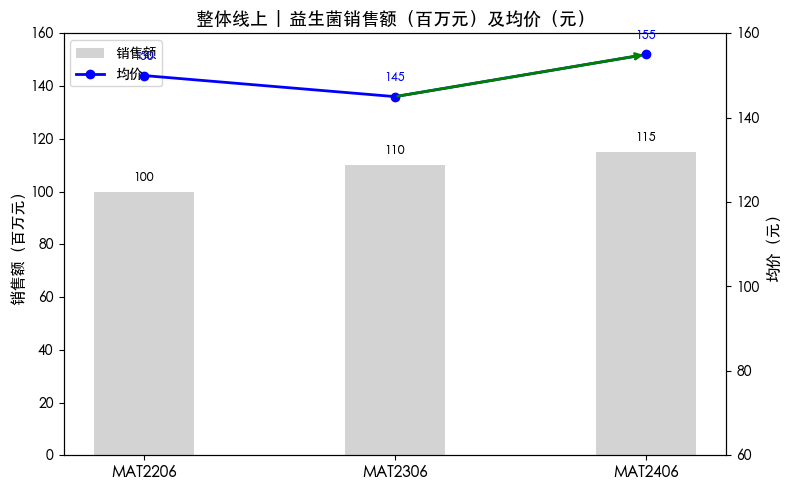

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 数据
periods = ['MAT2206', 'MAT2306', 'MAT2406']
sales = [100, 110, 115]
avg_price = [150, 145, 155]

x = np.arange(len(periods))

fig, ax1 = plt.subplots(figsize=(8, 5))

# 柱状图：销售额
bars = ax1.bar(x, sales, width=0.4, color='lightgray', label='销售额')
ax1.set_ylabel('销售额（百万元）', fontsize=11)
ax1.set_ylim(0, 160)

# 在柱子顶部添加数值标签
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 3, f'{sales[i]}',
             ha='center', va='bottom', fontsize=9)

# 折线图：均价
ax2 = ax1.twinx()
line, = ax2.plot(x, avg_price, color='blue', marker='o', linewidth=2, label='均价')
ax2.set_ylabel('均价（元）', fontsize=11)
ax2.set_ylim(60, 160)

# 在折线上标注数值
for i, price in enumerate(avg_price):
    ax2.text(x[i], price + 3, f'{price}', ha='center', va='bottom', fontsize=9, color='blue')

# 标注箭头（趋势）
ax2.annotate('', xy=(2, avg_price[2]), xytext=(1, avg_price[1]),
             arrowprops=dict(arrowstyle='->', color='green', lw=2))

# 设置X轴
ax1.set_xticks(x)
ax1.set_xticklabels(periods, fontsize=11)

# 标题
plt.title("整体线上 | 益生菌销售额（百万元）及均价（元）", fontsize=13)

# 合并图例
lines = [bars, line]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()
